### Dependencies

In [2]:
from pydantic import BaseModel
from typing import Literal, Dict, Any, Annotated, List
from operator import add
from jinja2 import Template
from IPython.display import Image, display
import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery


from langsmith import traceable, get_current_run_tree

import openai

In [4]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )
    return response.data[0].embedding


def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

def process_context(context):

    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

In [5]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [ ]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )
    return response.data[0].embedding

In [8]:
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [ ]:
query= "Can I get a tablet?"

In [ ]:
answer = retrieve_data(query, qdrant_client, k=10)

### Multi-intent Questions

In [3]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [ ]:
answer = retrieve_data(query, qdrant_client, k=10)

In [ ]:
#this won't be a desirable output
answer

{'retrieved_context_ids': ['B0B157WDDJ',
  'B0BN58Z4YX',
  'B0B159KDFP',
  'B0BGHBL86V',
  'B0BZM8YN4K',
  'B0C7DCS2KW',
  'B0BHVF13PY',
  'B0B3R74TZC',
  'B0BM657X74',
  'B0BT83RRJ2'],
 'retrieved_context': ["G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Pink 🤗【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 🤗【Kids-proof Case & Eye-protection Screen】G-TiDE's exclusive kids tablet case is made of impact-resistant EVA material. When your kid i

### Instructor

In [5]:
class QueryExpandRespone(BaseModel):
    statements: List[str]

In [6]:
def query_expansion_node(query) -> dict:
    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-nano",
        mode= instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response= client.create_with_completion(
        messages=[
                {"role": "system", "content": prompt}
            ],
            reasoning={"effort": "none"},
            response_model= QueryExpandRespone
    )

    return {
        "queries": response.statements
    }

In [7]:
answer = query_expansion_node(query)

In [8]:
answer

{'queries': ['Kid’s tablet',
  'Smartwatch for personal use',
  'Laptop for everyday work']}

### LangGraph

#### Query Expansion (Sequential Execution)

In [9]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""

### Query Expansion/ Rewriting Node

In [10]:
class QueryExpandRespone(BaseModel):
    statements: List[str]

In [12]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

## Instructions

- Expand the question into 1-5 concise statements.
- Each statement should capture a separate product or attribute from the query.
- Use natural product-description language.
- Do not produce multiple statements that express the same intent.

## Examples

Question: "Can I get earphones for me and a waterproof speaker?"
Statements:
- "Personal earphones"
- "Waterproof speaker"

Question: "I need a warm winter jacket for hiking"
Statements:
- "Insulated winter jacket"
- "Hiking outerwear for cold weather"

Question: "Do you have any toys?"
Statements:
- "Toys"

<question>
{{ query }}
</question>
"""

    template = Template(prompt_template)

    prompt = template.render(
        query=state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode= instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response= client.create_with_completion(
        messages=[
                {"role": "system", "content": prompt}
            ],
            reasoning={"effort": "none"},
            response_model= QueryExpandRespone
    )

    return {
        "expanded_query": response.statements
    }

### Retriever Node

In [37]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "text-embedding-3-small"
    }
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=text,
        model=model
    )

    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"] = {
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens,
        }

    return response.data[0].embedding


@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)

    if hybrid:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="text-embedding-3-small",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="text-embedding-3-small",
            limit=k
        )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context


@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = []

    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client, k=5))

    return {
        "retrieved_context": retrieved_context
    }


### Aggregator Node

In [26]:
class AggregatorResponse(BaseModel):
    answer: str

In [29]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

### Instructions

- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

### Context

{{ preprocessed_context }}

### Question

{{ question }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        preprocessed_context = preprocessed_context,
        question = state.initial_query
    )

    client = instructor.from_provider(
        "openai/gpt-5.4-mini",
        mode= instructor.Mode.RESPONSES_TOOLS
    )

    response, raw_response= client.create_with_completion(
        messages=[
                {"role": "system", "content": prompt}
            ],
            reasoning={"effort": "none"},
            response_model= AggregatorResponse
    )

    return {
        "answer": response.answer
    }

In [30]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)


workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

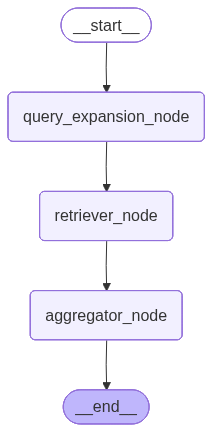

In [31]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
query = "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"

In [33]:
initial_state = {
    "initial_query": query
}

In [34]:
result = graph.invoke(initial_state)

In [35]:
result

{'expanded_query': ['Tablet for a child',
  'Watch for adult use',
  'Laptop for spouse'],
 'retrieved_context': ["- ID: B0B159KDFP, rating: 4.1, description: G-TiDE Kids Tablet, 7 inch Tablet for Kids, 32GB+2GB Kids Learning Tablet, 5MP Dual Camera HD, Parental Control App- KLAP, Toddler Tablet Case, WiFi Tablets Shoulder Straps, Blue 💙 【Explore More Fun on Klap】G-TiDE Klap kids tablet is designed for learning and playing. This tablet for kids offers various creative contents such as brain training, painting, gaming, kids TV, etc. Learning while playing is better for kids to know the world. With a 32GB bigger storage, which can be extended to 128GB (micro SD card not included), this kids tablet is perfect for children aged 3-7 years old. You could get more educational apps from Google Play Store (GMS). 💙 【Kids-proof Case & Eye-protection Screen】G-TiDE's exclusive kids tablet case is made of impact-resistant EVA material. When your kid is playing outdoors with the tablet or accidentall

In [36]:
print(result["answer"])

Yes — based on the available products, you can choose:

- For your kid: G-TiDE Kids Tablet (Blue or Pink)
  - 7-inch kids learning tablet
  - 32GB storage + 2GB RAM
  - Storage expandable up to 128GB with microSD card (not included)
  - 5MP dual camera
  - Parental control app: KLAP
  - Includes toddler tablet case and shoulder strap
  - Designed for ages 3–7
  - Good for learning and play with content like brain training, painting, gaming, and kids TV
  - Rating: 4.1 (Blue) / 3.9 (Pink)

- For you: woednx Smart Watch (Green Bands)
  - Smart watch available in the available products
  - Color: green bands
  - Rating: 3.9
  - No further specifications are provided in the available products

- For your wife: Lenovo 2022 Newest Lightweight Chromebook 3
  - 11.6-inch HD screen
  - AMD Dual-Core A6-9220C processor
  - 4GB RAM
  - 32GB eMMC storage
  - Chrome OS
  - WiFi 5 and webcam
  - Lightweight design at 2.42 lb
  - Good for web browsing, remote work, study, and video calls
  - Rating: 